# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

## Plan de solución



In [44]:
# importar librerías
import pandas as pd 
from matplotlib import pyplot as plt

In [45]:
# leer conjuntos de datos en los DataFrames
insta_ord = pd.read_csv('instacart_orders.csv', sep=';')
products = pd.read_csv('products.csv', sep=';')
aisles = pd.read_csv('aisles.csv', sep=';')
departments = pd.read_csv('departments.csv', sep=';')
ord_prod =pd.read_csv('order_products.csv', sep=';')

In [46]:
# mostrar información del DataFrame
insta_ord.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [47]:
# mostrar información del DataFrame
products.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [48]:
# mostrar información del DataFrame
aisles.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [49]:
# mostrar información del DataFrame
departments.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


In [50]:
# mostrar información del DataFrame
ord_prod.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


## Conclusiones

Los archivos tienen un separador en común, cuentan con falta de datos en algunas columnas

## Plan de solución



--Los datos ausentes en la tabla instacart se encuentran en la columna de "dias transcurridos desde el ultimo pedido", no afecta ya que puede haber clientes nuevos por lo que se pueden rellenar NaN.
--Los datos ausentes en la tabla de order_products, son el la columna "orden secuencial en el que se añadio cada articulo al carrito", considero que no genera impacto y se pueden rellenar.
--Los datos ausentes en la tabla products en la columna de nombre del producto, esto debe revisrse y alertar, de momento podemos rellenarlos para saber cual es la afectacion en cantidad y conforme a ello realizar la investigación y corregir el error.
--Los duplicados identificados pertenecen al id de usuario que en este caso se duplican por pedidos nuevos, podemos eliminarlos, sin embargo hay que considerar que para el calculo de compra por usuario estos duplicados seráan necesarios, se deberia asegurar que el conteo sea acumulativo y tener por regra que el id de usuario no se repita bajo ninguna circunstancia.

### `instacart_orders` data frame

In [ ]:
# Revisa si hay pedidos duplicados
print('Duplicados al inicio: ', insta_ord.duplicated().sum())
print("Los duplicados encontrados son exactamente iguales en todas sus columnas")




Duplicados al inicio:  15
Los duplicados encontrados son exactamente iguales en todas sus columnas


¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

In [52]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
compras = insta_ord[(insta_ord['order_dow'] == 3) & (insta_ord['order_hour_of_day'] == 2)].count()
#compras2 = insta_ord[insta_ord['order_hour_of_day'] == 2]
total = compras.sum() 
print("El total de compras que se realizaron el miercoles a las 2am son: ",total)

El total de compras que se realizaron el miercoles a las 2am son:  719


¿Qué sugiere este resultado?

In [53]:
# Elimina los pedidos duplicados
insta_ord.drop_duplicates(inplace=True)
insta_ord.drop_duplicates().reset_index(drop=True)

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0
...,...,...,...,...,...,...
478947,3210681,5617,5,1,14,7.0
478948,3270802,112087,2,3,13,6.0
478949,885349,82944,16,2,11,6.0
478950,216274,4391,3,3,8,8.0


In [54]:
# Vuelve a verificar si hay filas duplicadas
print('Duplicados al final: ', insta_ord.duplicated().sum())

Duplicados al final:  0


In [55]:
# Vuelve a verificar si hay IDs duplicados de pedidos
print('Duplicados: ', insta_ord.duplicated().sum())
print()
print('Duplicados: ', products.duplicated().sum())
print()
print('Duplicados: ', aisles.duplicated().sum())
print()
print('Duplicados: ', departments.duplicated().sum())
print()
print('Duplicados: ', ord_prod.duplicated().sum())
print()
print("Aqui comprobamos que ya no existen duplicados")

Duplicados:  0

Duplicados:  0

Duplicados:  0

Duplicados:  0

Duplicados:  0

Aqui comprobamos que ya no existen duplicados


### `products` data frame

In [56]:
# Verifica si hay filas totalmente duplicadas
print('Duplicados: ', products.duplicated().sum())

Duplicados:  0


In [57]:
# Verifica si hay IDs duplicadas de productos
print('duplicados: ', products.duplicated('product_id').sum())

duplicados:  0


In [58]:
# Revisa si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
prod_names = products['product_name'].str.upper()
print('duplicados',prod_names.duplicated().sum())

duplicados 1361


In [59]:
# Revisa si hay nombres duplicados de productos no faltantes
print("Valores ausentes: ",products.isna().sum())
prod_na = products.dropna()
print("Valores ausentes: ",prod_na.isna().sum())
prod_na = prod_na['product_name'].str.upper()
print('Tenemos duplicados: ',prod_na.duplicated().sum())


Valores ausentes:  product_id          0
product_name     1258
aisle_id            0
department_id       0
dtype: int64
Valores ausentes:  product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64
Tenemos duplicados:  104



--Encontre 104 duplicados lo que considero debe hacerse es unificar y corregir esos duplicados para tener estadisrticas mpas precisas.

### `departments` data frame

In [60]:
# Revisa si hay filas totalmente duplicadas
print("Duplicados: ",departments.duplicated().sum())

Duplicados:  0


In [61]:
# Revisa si hay IDs duplicadas de productos
print("Duplicados: ",departments['department_id'].duplicated().sum())

Duplicados:  0


### `aisles` data frame

In [62]:
# Revisa si hay filas totalmente duplicadas
print("Duplicados: ",'duplicados: ',aisles.duplicated().sum())

Duplicados:  duplicados:  0


In [63]:
# Revisa si hay IDs duplicadas de productos
print('Tenemos duplicados: ',aisles['aisle_id'].duplicated().sum() )

Tenemos duplicados:  0



--En esta tabla no se han enciontrado duplicados.

### `order_products` data frame

In [64]:
# Revisa si hay filas totalmente duplicadas
print('Tenemos duplicados: ',ord_prod.duplicated().sum())

Tenemos duplicados:  0


In [65]:
## Vuelve a verificar si hay cualquier otro duplicado engañoso


### `products` data frame

In [66]:
# Encuentra los valores ausentes en la columna 'product_name'
print('Tenemos valores ausentes al inicio: ',products.isna().sum())
products.head(20)

Tenemos valores ausentes al inicio:  product_id          0
product_name     1258
aisle_id            0
department_id       0
dtype: int64


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
5,6,Dry Nose Oil,11,11
6,7,Pure Coconut Water With Orange,98,7
7,8,Cut Russet Potatoes Steam N' Mash,116,1
8,9,Light Strawberry Blueberry Yogurt,120,16
9,10,Sparkling Orange Juice & Prickly Pear Beverage,115,7


In [67]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
prod_aus = products
prod_aus2 = prod_aus.fillna(value=999)
print(prod_aus2[prod_aus2['product_name']==999])

print('Si, todos los ausentes tienen el id 100 y el mismo departamento.')

       product_id product_name  aisle_id  department_id
37             38          999       100             21
71             72          999       100             21
109           110          999       100             21
296           297          999       100             21
416           417          999       100             21
...           ...          ...       ...            ...
49552       49553          999       100             21
49574       49575          999       100             21
49640       49641          999       100             21
49663       49664          999       100             21
49668       49669          999       100             21

[1258 rows x 4 columns]


Si, todos los ausentes tienen el id 100 y el mismo departamento.


--Todos los ausentes tienen el id 100 y el mismo departamento.

# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
Si todos pertenecen al mismo departamento.

--Si todos pertenecen al mismo departamento.

In [68]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
print(departments[departments['department_id']== 21])
print(aisles[aisles['aisle_id']==100])


    department_id department
20             21    missing
    aisle_id    aisle
99       100  missing



--El pasillo y el departamento corresponden a "missing"

In [69]:
# Completa los nombres de productos ausentes con 'Unknown'
products['product_name'] = products['product_name'].fillna(value='unknown')
products.isna().sum()

product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64


--Hemos rellenado las filas ausentes para mejor certeza.

### `orders` data frame

In [70]:
# Encuentra los valores ausentes
insta_ord.isna().sum()

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64

In [71]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
ord_prod.isna().sum()
vacio = ord_prod
vacio = vacio.fillna(value='uno')
vacias = vacio.merge(insta_ord, on='order_id')
print(vacias[vacias['add_to_cart_order']=='uno'])

print("Si, hay muchos valores que se encuentran ausentes, y los clientes ya han comprado con anterioridad")


         order_id  product_id add_to_cart_order  reordered  user_id  \
737       2449164        5068               uno          0   170548   
9926      1968313       43867               uno          0    10009   
14394     2926893       11688               uno          0   166743   
16418     1717990        4142               uno          0    60694   
30114     1959075       42828               uno          1   201268   
...           ...         ...               ...        ...      ...   
4505662   1800005        7411               uno          0   157473   
4511400   1633337         260               uno          0    26618   
4517562    404157        9517               uno          0    22906   
4534112   1673227       17835               uno          0   129928   
4535739   1832957       17949               uno          1   129928   

         order_number  order_dow  order_hour_of_day  days_since_prior_order  
737                55          2                 12                  



--En mi anterior respuesta dije que todos eran de primer compra, veo que me habia confundico ya que los busque en otra tabla, compruebo que hay usuarios que ya habían comprado con anterioridad.

### `order_products` data frame

In [72]:
# Encuentra los valores ausentes
ord_prod.isna().sum()

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

In [73]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
minimo = ord_prod['add_to_cart_order'].min()
maximo = ord_prod['add_to_cart_order'].max()
print('El valor minimo es: ',minimo)
print('El valor maximo es: ',maximo)

El valor minimo es:  1.0
El valor maximo es:  64.0


In [74]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
val_aus = ord_prod
val_aus = val_aus.fillna(value='temp')
val2 = val_aus[val_aus['add_to_cart_order'] == 'temp']
val3 = val2['order_id']
val3.head(10)

737      2449164
9926     1968313
14394    2926893
16418    1717990
30114    1959075
34183     844733
57981      61355
58228     936852
62655     264710
64336    1717990
Name: order_id, dtype: int64

In [75]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
filtro = insta_ord.merge(val3, left_on='order_id', right_on='order_id',suffixes=['order_hour_of_day', 'days_since_prior_order'])
print(filtro)
print('Los valores que se encontraron el maximo es de 30, ninguno llega a 60')
print(filtro['days_since_prior_order'].max())
print()
print(filtro['days_since_prior_order'].min())
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
grup = ord_prod.groupby('order_id')
print('El minimo por id de producto es: ',grup['product_id'].count().min())
print()
print('El maximo por id de producto es: ',grup['product_id'].count().max())
print()
print(grup.count())
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.


     order_id  user_id  order_number  order_dow  order_hour_of_day  \
0     1916118   166951            15          1                  9   
1     1916118   166951            15          1                  9   
2     1916118   166951            15          1                  9   
3      165801   180033             1          1                 14   
4      165801   180033             1          1                 14   
..        ...      ...           ...        ...                ...   
831    844733   126266             9          5                  9   
832    844733   126266             9          5                  9   
833   2625444   123044             8          0                  0   
834   2625444   123044             8          0                  0   
835   2625444   123044             8          0                  0   

     days_since_prior_order  
0                      14.0  
1                      14.0  
2                      14.0  
3                       NaN  
4        



--El minimo del id de producto es uno algo esperado y el maximo 127.

In [76]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
ord_prod['add_to_cart_order'] = ord_prod['add_to_cart_order'].fillna(value=999)
ord_prod['add_to_cart_order'].isna().sum()
ord_prod['add_to_cart_order'] = pd.to_numeric(ord_prod['add_to_cart_order'], errors='coerce')
ord_prod['add_to_cart_order'] = ord_prod['add_to_cart_order'].astype('int')
ord_prod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 138.7 MB




Unimos los valores ausentes con la tabla de ordenes y pudimo saber los maximos y minimos de las ordenes.

## Conclusiones


--Se pudo trabajar con los datos, los ausentes no generan impacto en este caso, se eliminaron los duplicados y se rellenaron los ausentes.


###  Verifica que los valores sean sensibles

El valor minimo de hora es:  0

El valor maximo de hora es:  23
El valor minimo dow es:  0

El valor maximo dow es:  6


<Axes: title={'center': 'Compras x día'}, xlabel='Dias', ylabel='Usuarios'>

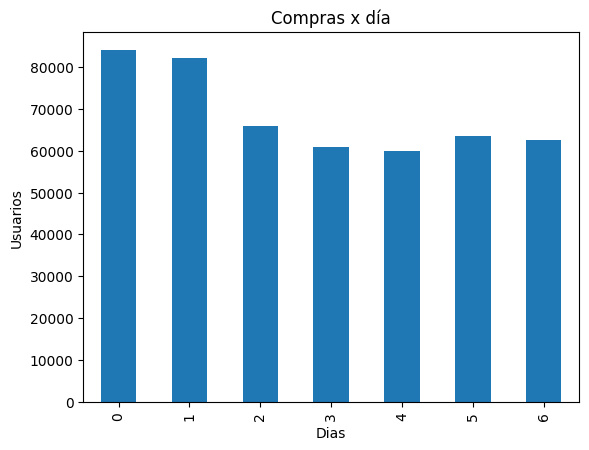

In [77]:
print('El valor minimo de hora es: ',insta_ord['order_hour_of_day'].min())
print()
print('El valor maximo de hora es: ',insta_ord['order_hour_of_day'].max())

print('El valor minimo dow es: ',insta_ord['order_dow'].min())
print()
print('El valor maximo dow es: ',insta_ord['order_dow'].max())

dxgp = gday = insta_ord.groupby('order_dow')['user_id'].count()

dxgp.head(10).plot(x='order_dow', y='user_id', kind='bar', title='Compras x día', xlabel='Dias', ylabel='Usuarios')

<Axes: title={'center': 'Lapso de tiempo entre compras'}, xlabel='Días desde ultima compra', ylabel='Usuarios'>

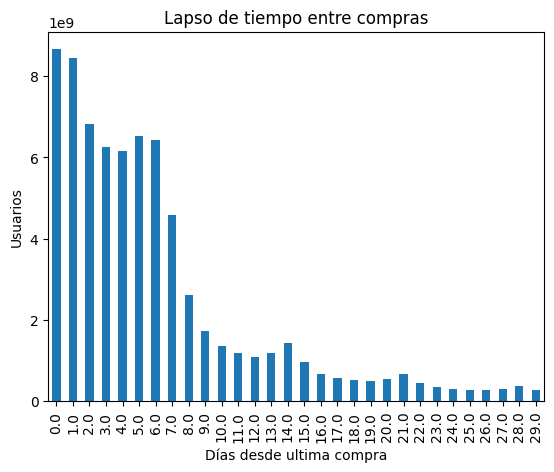

In [78]:
date = 30
comday = insta_ord.groupby('order_dow')['user_id'].sum()
comday.head(date).plot(x='order_dow', y='user_id', kind='bar', title='Compras por día', xlabel='Dias', ylabel='Usuarios')

comlast = insta_ord.groupby('days_since_prior_order')['user_id'].sum()
comlast.head(date).plot(x='days_since_prior_order', y='user_id', kind='bar', title='Lapso de tiempo entre compras', xlabel='Días desde ultima compra', ylabel='Usuarios')



--Hay más compras entre las 10 y 16h.
--Tenemos un mayor volumen de compra los días Domingo y lunes
--La mayor cantidad de usuarios tarda hasta 30 días, en segundo lugar hasta 7 días, y por ultimo vemos una gran cantidad de clientes nuevos o que realizan su primer compra.

###  Para cada hora del día, ¿cuántas personas hacen órdenes?

<Axes: title={'center': 'Compras segun horario'}, xlabel='Horas', ylabel='Usuarios'>

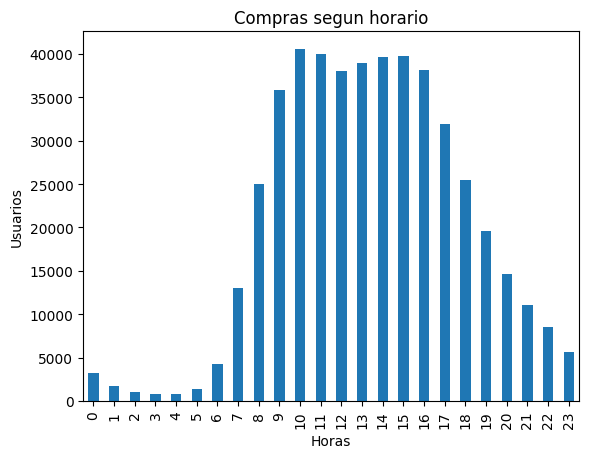

In [79]:
comxh = insta_ord.groupby('order_hour_of_day')['user_id'].count()
comxh.head(date).plot(x='order_hour_of_day', y='user_id', kind='bar', title='Compras segun horario', xlabel='Horas', ylabel='Usuarios')



--Usuarios compran más entre 11 y 12 del día.

###  ¿Qué día de la semana compran víveres las personas?

<Axes: title={'center': 'Compras x día'}, xlabel='Dias', ylabel='Usuarios'>

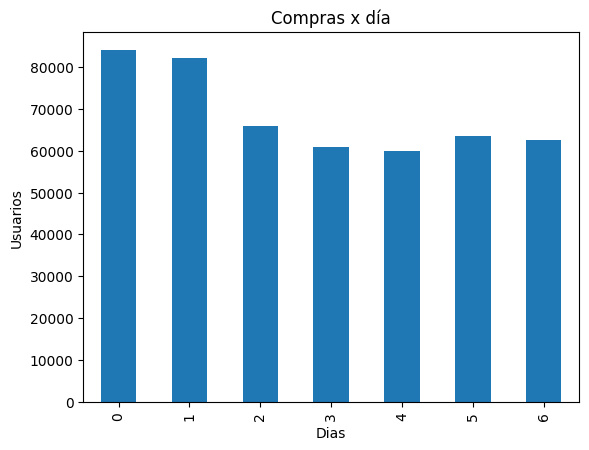

In [80]:
gday = insta_ord.groupby('order_dow')['user_id'].count()

gday.head(10).plot(x='order_dow', y='user_id', kind='bar', title='Compras x día', xlabel='Dias', ylabel='Usuarios')



--Los dias domingo y lunes es cuando compran más.



###  ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

<Axes: xlabel='days_since_prior_order'>

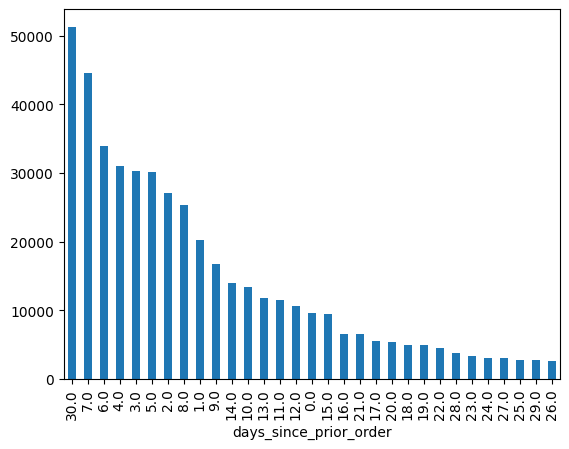

In [ ]:

add = insta_ord['days_since_prior_order'].value_counts().sort_values(ascending=False)
add.plot(x='insta_ord',kind='bar')



--En este caso vemos que como minimo sera un día, ya que el cero se refiere a los clientes nuevos o de promera compra, el maximo y másn alto porcentaje es de hasta 30 días.

###  Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

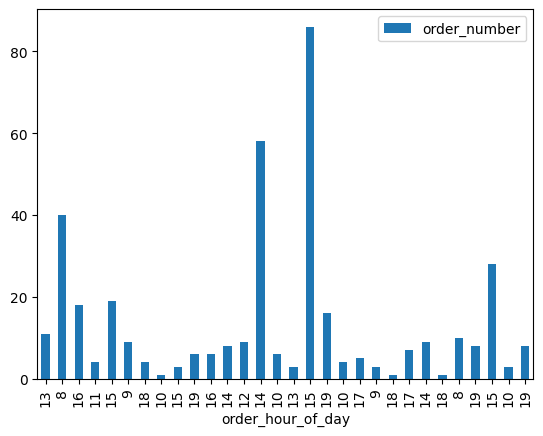

In [82]:
fall = [3,6]
filter = insta_ord[insta_ord['order_dow'].isin(fall)][['order_hour_of_day','order_number','order_dow']]

filter2 = filter.groupby('order_dow')['order_hour_of_day'].count()

#filter2.head(30).plot(y='order_dow',x='order_hour_of_day',kind='bar',rot='50', xlabel='Dias',ylabel='Compras')

filter.head(30).plot(x='order_hour_of_day',y='order_number',kind='bar')
plt.show()

Obserbamos las compras que se realizaron Miercoles "3", y Sábado "6"


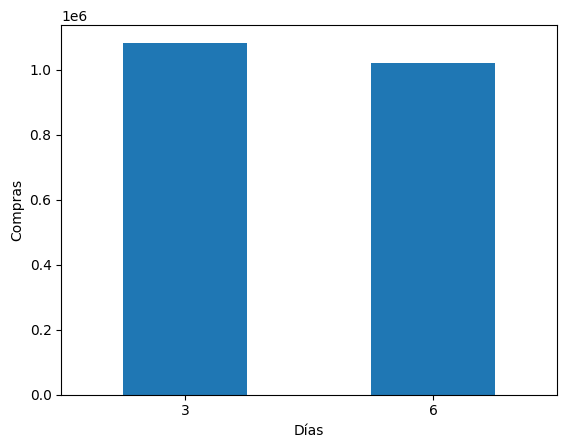

In [83]:
fall = [3,6]
filter = insta_ord[insta_ord['order_dow'].isin(fall)][['order_number','order_dow']]
filter2 = filter.groupby('order_dow')['order_number'].sum()
filter2.head(30).plot(x='order_dow',y='order_number',kind='bar',rot='horizontal', ylabel='Compras',xlabel='Días')

print('Obserbamos las compras que se realizaron Miercoles "3", y Sábado "6"')

Las compras realizan en los diferentes dias de la semana


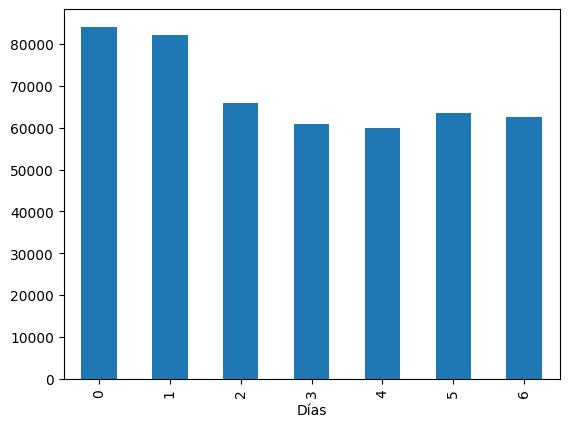

In [84]:
dfgp = insta_ord.groupby('order_dow')['user_id'].count()
dfgp.plot(x='order_dow',y='',kind='bar',xlabel='Días')
print('Las compras realizan en los diferentes dias de la semana')



--Hay más compras en sabado entre las 13 y 16 horas.
--En miercoles el mayor numero de comras de ese día son entre las 15 y 16 horas.
--Menor numero de compras es muy parejo se registra entre las 2 y 3 horas de ambos días.

###  ¿Cuál es la distribución para el número de pedidos por cliente?

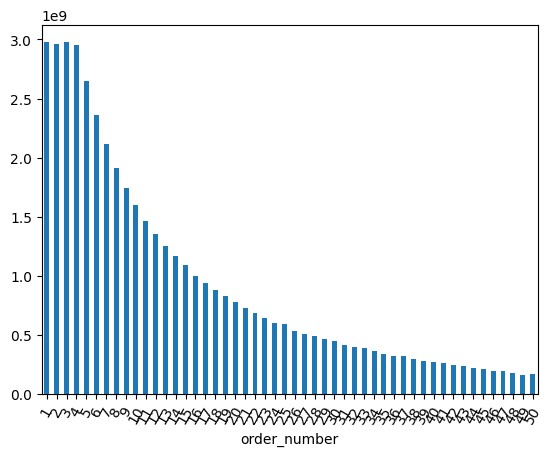

In [85]:
nfilas = 50
pedxcliente = insta_ord.groupby('order_number')['user_id'].sum()
pedxcliente.head(nfilas).plot(x='order_number',y='user_id',kind='bar',rot= 60)
plt.show()




--Aqui no lo veo ya que no puedo graficar completo, sin embargo el porcentaje de clientes que hacer entre 1 y 6 pedidos es mas alto y conforme crecen los pedidos disminuyen la cantidad de clientes. 

###  ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

<Axes: xlabel='product_name'>

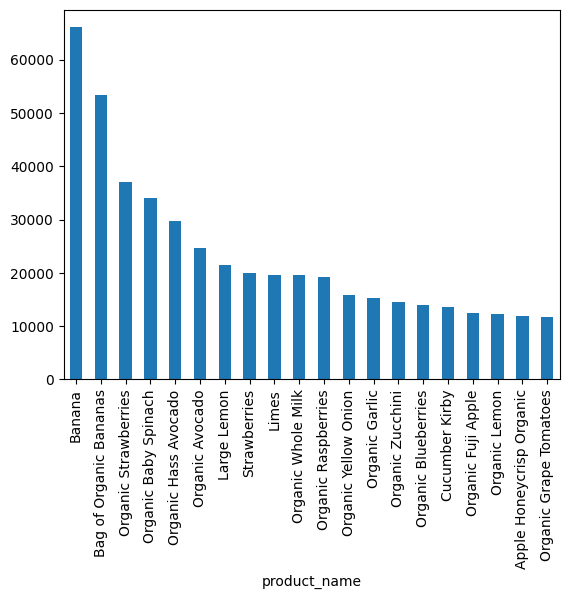

In [ ]:
men_com = pd.merge(ord_prod, products, on='product_id')
mengp = men_com.groupby('product_name')['product_id'].count() 
mengp2 = mengp.sort_values(ascending=False)
mengp2.head(20).plot(x='product_name',y='product_id',kind='bar')



--Muchos productos con el mismo nombre pero diferente id por lo que se debe corregir ya que deberian tener el mismo id.

###  ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

<Axes: title={'center': 'Distribución de productos por orden'}, ylabel='Frequency'>

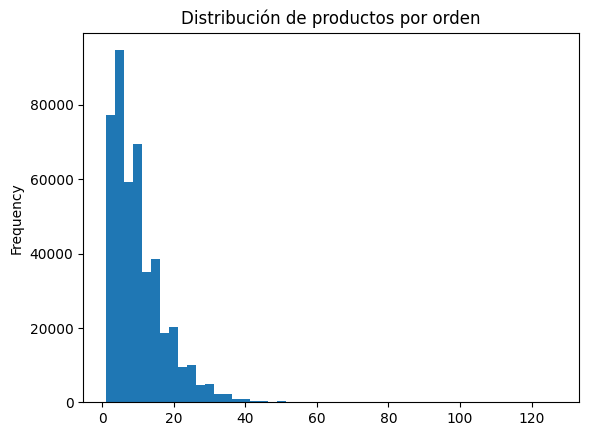

In [87]:
#numero de prod que compran
# 1. Cuentas los productos por orden
user_op = ord_prod.groupby('order_id')['product_id'].count()

# 2. Excluimos las órdenes que tengan 0 productos (el filtro que pedías)
user_op = user_op[user_op > 0]

# 3. Haces el histograma directamente sobre user_op. 
# Le ponemos 'bins=50' para que las barras se vean bien definidas.
user_op.plot(kind='hist', bins=50, title='Distribución de productos por orden')



--Creo que ya quedo la fecuencia.

--"En algunas secciones utilizo el 'head' debido a que el kernel muere, por lo que no ejecuta, no se a que se deba jeje por ello uso el he

###  ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

<Axes: xlabel='product_name'>

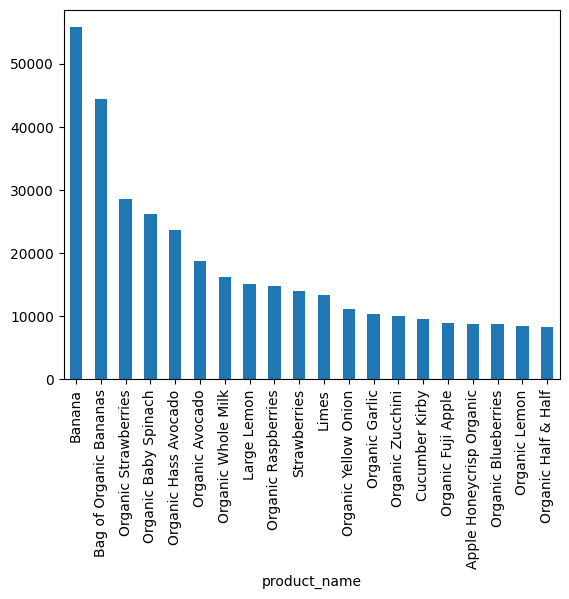

In [88]:
produ = pd.merge(ord_prod, products, on='product_id') #unimos las tablas
produc = ord_prod[ord_prod['reordered']==1]
produc1 = produc.merge(products, on='product_id')
produc2 = produc1.groupby('product_name')['product_id'].count()
produc2 = produc2.sort_values(ascending=False)
produc2.head(20).plot(x='product_name', kind='bar')







--Observamos que hay mayor tendencia hacia los productos organicos

###  Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [89]:
#veces que el cliente ordena
user = ord_prod.merge(insta_ord, on='order_id')
user_order = user.groupby('product_id')['reordered'].sum()
user_order = user_order.sort_values(ascending=False)
user_order2 = products.merge(user_order, on='product_id')
user_order2 = user_order2.sort_values('reordered',ascending=False)
user_order2.head(20)

,product_id,product_name,aisle_id,department_id,reordered
22808,24852,Banana,24,4,55763
12025,13176,Bag of Organic Bananas,24,4,44450
19370,21137,Organic Strawberries,24,4,28639
20077,21903,Organic Baby Spinach,123,4,26233
43271,47209,Organic Hass Avocado,24,4,23629
43788,47766,Organic Avocado,24,4,18743
25556,27845,Organic Whole Milk,84,16,16251
43663,47626,Large Lemon,24,4,15044
25666,27966,Organic Raspberries,123,4,14748
15364,16797,Strawberries,24,4,13945


In [90]:
user_reordered = user.groupby('user_id')['product_id'].count()  # veces que el cliente vuelve a ordenar
user_reordered

user_id
2          26
4           2
5          12
6           4
7          14
         ... 
206203     27
206206     21
206207     46
206208    125
206209     25
Name: product_id, Length: 149626, dtype: int64

In [91]:
prop = user_order/user_reordered  ## Esta seria la proporcion
print(prop)
print()
prop2 = user_reordered/user_order
print(prop2)

1          NaN
2          0.0
3          NaN
4         12.5
5          NaN
          ... 
206203     NaN
206206     NaN
206207     NaN
206208     NaN
206209     NaN
Length: 162174, dtype: float64

1          NaN
2          inf
3          NaN
4         0.08
5          NaN
          ... 
206203     NaN
206206     NaN
206207     NaN
206208     NaN
206209     NaN
Length: 162174, dtype: float64




--Aqui considere las ordenes de los usuarios entre las ordenes que se volvierona realizar, pero francamente no tengo claro cual es la proporcion correcta, por ello deje las dos operaciones.

###  Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [92]:
cliente = insta_ord.merge(ord_prod, on='order_id')
cliente2 = cliente.groupby('user_id')['order_id'].count()
productos = cliente.groupby('order_id')['add_to_cart_order'].sum()
productos = productos.sort_values(ascending=False)  #productos que ya habian ordenado
productos

order_id
61355      65017
3308010    53029
2136777    46036
171934     42040
1959075    36046
           ...  
2025935        1
2026085        1
3253891        1
3253985        1
3254047        1
Name: add_to_cart_order, Length: 450046, dtype: int64



--Saber cuales son los productos que mas se compran nos da una idea de cuales pueden ser las preferencias de los usuarios

###  ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [93]:
carrito = ord_prod.merge(products, on='product_id')
carrito1 = carrito[carrito['add_to_cart_order']==1]
carrito2 = carrito1.groupby('product_name')['product_id'].count()
carrito3 = carrito2.sort_values(ascending=False)
carrito3.head(20)
#muestra = products.merge(carrito3, on='product_id')
#muestra.head(20)
### Aqui ya no pude ordenarlos 

product_name
Banana                         15562
Bag of Organic Bananas         11026
Organic Whole Milk              4363
Organic Strawberries            3946
Organic Hass Avocado            3390
Organic Baby Spinach            3336
Organic Avocado                 3044
Spring Water                    2336
Strawberries                    2308
Organic Raspberries             2024
Sparkling Water Grapefruit      1914
Organic Half & Half             1797
Large Lemon                     1737
Soda                            1733
Organic Reduced Fat Milk        1397
Limes                           1370
Hass Avocados                   1340
Organic Reduced Fat 2% Milk     1310
Half & Half                     1309
Organic Yellow Onion            1246
Name: product_id, dtype: int64


-- La preferida es la banana, leche entera y otros productos organicos.

### Conclusion general del proyecto:

Empezamos con la carga de los archivos, realice una exploracion de los datos, encontrando, duplicados y otros ausentes,
mismos que se decidi eliminar los duplicados ya que no afectan en el resultado, la sugerencia es tener identificados 
los duplicados para corregir y evitar que se generen duplicidad de información, el los nombres de los productos sugiero que 
se homogenice los nombres, y determinar porque es que tenemos ausencia en estos.
Observamos qque los dias en los que mas compras se realizan es en los días domingo y lunes, de alli comienzan a haber menos
compras, al igual que se registran más compras por la tarde, los usuarios tienen preferencia por las bananas, leche entera y
algunos otros productos organicos.